In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.extract import extract_data, to_csv


# 1. Data Extraction

## Data Dictionary

| Column | Description |
|----------|----------|
| date | Trading date |
| ticker | Stock ticker |
| open | Opening price |
| high | Highest price |
| low | Lowest price |
| close | Closing price |
| volume | Shares traded |
| daily_return | Daily percentage return |
| ma_30 | 30-day moving average |
| volatility_30d | 30-day rolling volatility |

## Tickers:
- NVDA: Nvidia Corporation
- GOOG: Alphabet Inc. (Google)
- AAPL: Apple Inc.
- MSFT: Microsoft 
- AMZN: Amazon.com, Inc.
- TSM: Taiwan Semiconductor Manufacturing Company (TSMC)
- AVGO: Broadcom 
- 2222.SR: Saudi Aramco
- 005930.KS: Samsung Group
- TSLA: Tesla, Inc
- META: Meta Platforms (Facebook)
- MU: Micron Technology
- 000660.KS: SK Hynix
- BRK-B: Berkshire Hathaway Inc.
- LLY: Eli Lilly
- WMT: Walmart Inc.
- JPM: JPMorgan Chase
- AMD: Advanced Micro Devices
- V: Visa Inc.
- INTC: Intel Corporation

In [3]:
tickers = ["NVDA", "GOOG", "AAPL", "MSFT", "AMZN", "TSM", "AVGO", "2222.SR", "005930.KS", "TSLA", "META", "MU", "000660.KS", "BRK-B", "LLY", "WMT", "JPM", "AMD", "V", "INTC"]

In [4]:
data = extract_data(tickers, "2023-01-01")

[*********************100%***********************]  20 of 20 completed


In [5]:
prices = (
    data
    .stack(level=0)
    .reset_index()
    .rename(columns={
        "Date": "date",
        "level_1": "ticker",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume"
    })
)

C:\Users\elton\AppData\Local\Temp\ipykernel_70612\2625480374.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data


In [6]:
prices.columns = prices.columns.str.lower()

In [7]:
raw_prices = prices.copy(deep=True)
to_csv(raw_prices, "../data/raw/raw_stock_prices.csv")

# 2. Data Exploration

In [8]:
def basic_exploration(df):
    print(f'Data shape: {df.shape}')
    print(f'Data info: ')
    display(df.info())
    print(f'Describe numerical data: ')
    display(df.describe())
    print(f'Describe categorical data: ')
    display(df.describe(include='O'))

In [9]:
basic_exploration(prices)

Data shape: (17688, 7)
Data info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17688 entries, 0 to 17687
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17688 non-null  datetime64[ns]
 1   ticker  17688 non-null  object        
 2   open    17688 non-null  float64       
 3   high    17688 non-null  float64       
 4   low     17688 non-null  float64       
 5   close   17688 non-null  float64       
 6   volume  17688 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 967.4+ KB


None

Describe numerical data: 


Price,date,open,high,low,close,volume
count,17688,1.768800e+04,1.768800e+04,1.768800e+04,1.768800e+04,1.768800e+04
mean,2024-10-08 15:18:14.165536,2.333470e+04,2.392170e+04,2.279542e+04,2.336131e+04,4.371762e+07
min,2023-01-01 00:00:00,1.444191e+01,1.453171e+01,1.400289e+01,1.423337e+01,0.000000e+00
25%,2023-11-17 00:00:00,1.134114e+02,1.151438e+02,1.117053e+02,1.135074e+02,8.680498e+06
50%,2024-10-08 00:00:00,2.193454e+02,2.224978e+02,2.160901e+02,2.195700e+02,1.884874e+07
75%,2025-08-28 00:00:00,4.106309e+02,4.150778e+02,4.057725e+02,4.106204e+02,4.297518e+07
max,2026-07-17 00:00:00,2.898000e+06,2.987000e+06,2.749000e+06,2.919000e+06,1.543911e+09
std,NaN,1.426044e+05,1.474857e+05,1.377759e+05,1.425671e+05,8.291531e+07


Describe categorical data: 


Price,ticker
count,17688
unique,20
top,AAPL
freq,887


In [10]:
def select_numeric(df):
    return df.select_dtypes(include=np.number)

prices_numeric = select_numeric(prices)

In [11]:
prices.isna().groupby(prices["ticker"]).sum()

Price,date,ticker,open,high,low,close,volume
ticker,,,,,,,
000660.KS,0,0,0,0,0,0,0
005930.KS,0,0,0,0,0,0,0
2222.SR,0,0,0,0,0,0,0
AAPL,0,0,0,0,0,0,0
AMD,0,0,0,0,0,0,0
AMZN,0,0,0,0,0,0,0
AVGO,0,0,0,0,0,0,0
BRK-B,0,0,0,0,0,0,0
GOOG,0,0,0,0,0,0,0


In [12]:
prices.groupby("ticker")["date"].agg(["min","max","count"])

,min,max,count
ticker,,,
000660.KS,2023-01-02,2026-07-16,862
005930.KS,2023-01-02,2026-07-16,862
2222.SR,2023-01-01,2026-07-16,885
AAPL,2023-01-03,2026-07-17,887
AMD,2023-01-03,2026-07-17,887
AMZN,2023-01-03,2026-07-17,887
AVGO,2023-01-03,2026-07-17,887
BRK-B,2023-01-03,2026-07-17,887
GOOG,2023-01-03,2026-07-17,887


In [13]:
prices.groupby("ticker").size()

ticker
000660.KS    862
005930.KS    862
2222.SR      885
AAPL         887
AMD          887
AMZN         887
AVGO         887
BRK-B        887
GOOG         887
INTC         887
JPM          887
LLY          887
META         887
MSFT         887
MU           887
NVDA         887
TSLA         887
TSM          887
V            887
WMT          887
dtype: int64

Different exchanges have different trading calendars resulting in different observation counts.

In [14]:
coverage = (
    prices.groupby("ticker")
    .agg(
        start_date=("date","min"),
        end_date=("date","max"),
        observations=("date","count")
    )
)

coverage

,start_date,end_date,observations
ticker,,,
000660.KS,2023-01-02,2026-07-16,862
005930.KS,2023-01-02,2026-07-16,862
2222.SR,2023-01-01,2026-07-16,885
AAPL,2023-01-03,2026-07-17,887
AMD,2023-01-03,2026-07-17,887
AMZN,2023-01-03,2026-07-17,887
AVGO,2023-01-03,2026-07-17,887
BRK-B,2023-01-03,2026-07-17,887
GOOG,2023-01-03,2026-07-17,887


Four OHLC inconsistencies were detected after rounding adjusted price data. Since the deviations are small and likely introduced by precision/adjustment effects, the records were not manually overwritten. The validation is retained in the data quality report.

In [15]:
invalid_ohlc = prices[
        (prices["high"] < prices["open"]) |
        (prices["high"] < prices["close"]) |
        (prices["high"] < prices["low"]) |
        (prices["low"] > prices["open"]) |
        (prices["low"] > prices["close"])
    ]
invalid_ohlc

Price,date,ticker,open,high,low,close,volume
423,2023-02-02,000660.KS,92299.262061,92299.262061,90159.553140,88895.179688,8254.0
523,2023-02-09,000660.KS,92202.013929,92202.013929,90062.304745,92299.273438,12117.0
1816,2023-05-14,2222.SR,28.109606,28.151373,27.984302,28.151373,10000.0
4148,2023-10-31,005930.KS,64334.869161,65001.058635,63668.679688,63668.679688,14488892.0
8909,2024-10-14,000660.KS,184593.267137,189926.619960,184593.267137,183704.375000,3309274.0
8910,2024-10-14,005930.KS,57729.799747,59379.222597,57632.774874,57535.750000,20886249.0


# 3. Correlation Analysis

In [16]:
pivot_prices = prices.pivot(
    index="date",
    columns="ticker",
    values="close"
)

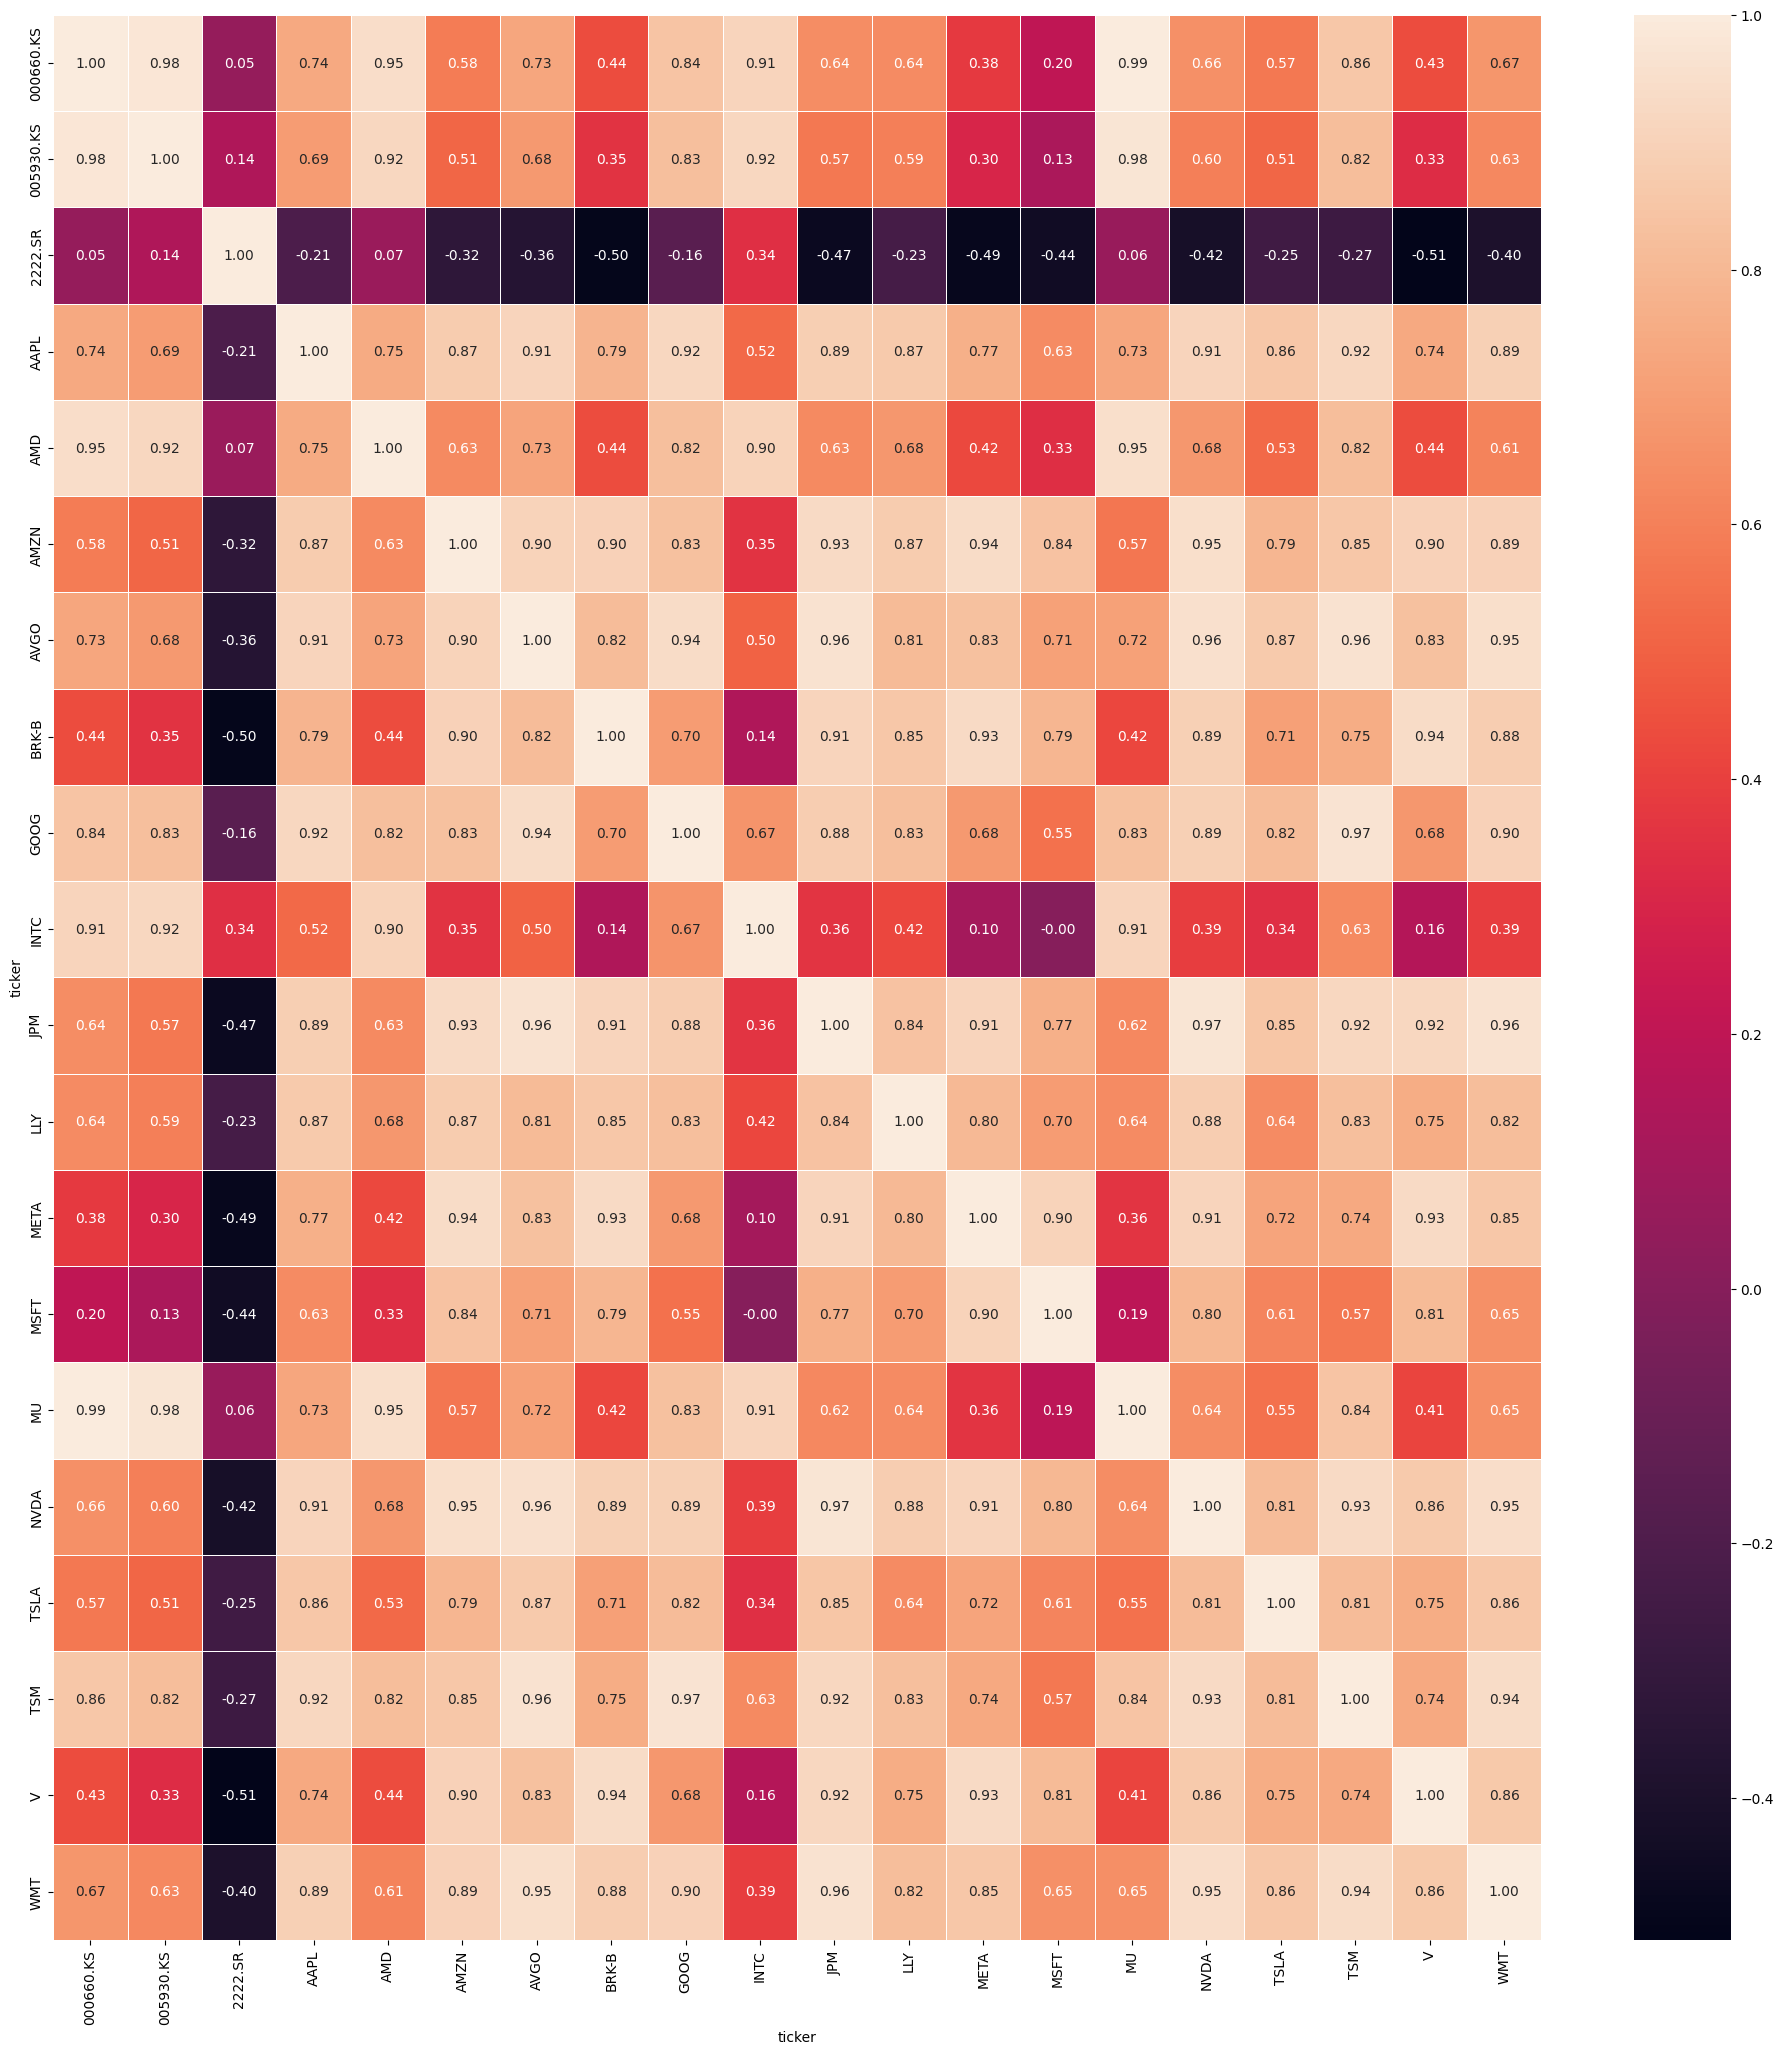

In [17]:
def check_correlation(df):
    fig, ax = plt.subplots(figsize=(24, 25))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=0.5)
    plt.show()
    
check_correlation(pivot_prices)

## Dataset Summary

In [18]:
print(f"""
Dataset Summary
---------------
Rows: {len(prices)}
Tickers: {prices['ticker'].nunique()}
Date Range: {prices['date'].min()} - {prices['date'].max()}
Features: {prices.shape[1]}
""")


Dataset Summary
---------------
Rows: 17688
Tickers: 20
Date Range: 2023-01-01 00:00:00 - 2026-07-17 00:00:00
Features: 7

